## 📦 Instalação de Dependências

Este bloco instala a biblioteca **OSMnx**, que permite baixar e analisar redes viárias urbanas diretamente do OpenStreetMap. É necessária apenas no primeiro uso (ex.: Google Colab).

In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 6.3 MB/s eta 0:00:00


## 📚 Importação das Bibliotecas

Importamos as bibliotecas utilizadas ao longo do notebook:

- **`osmnx`**: download e visualização de redes viárias do OpenStreetMap.
- **`networkx`**: análise de grafos (grau, betweenness, closeness, k-core, etc.).
- **`matplotlib`**: geração de gráficos e visualizações.
- **`Counter`** (collections): contagem de frequências para a distribuição de graus.

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

## 🗺️ Criação do Grafo da Rede Viária

Neste bloco definimos a área geográfica de estudo — o bairro **Potengi, Natal/RN** — e construímos o grafo da rede viária a partir do OpenStreetMap usando o OSMnx.

O grafo é do tipo **MultiDiGraph** (dígrafo com possibilidade de arestas paralelas), onde:
- **Nós** representam interseções e terminais de rua.
- **Arestas** representam segmentos de rua com direção.

Ao final, o mapa da rede é plotado e salvo como imagem.

Número de nós: 1481
Número de arestas: 3900


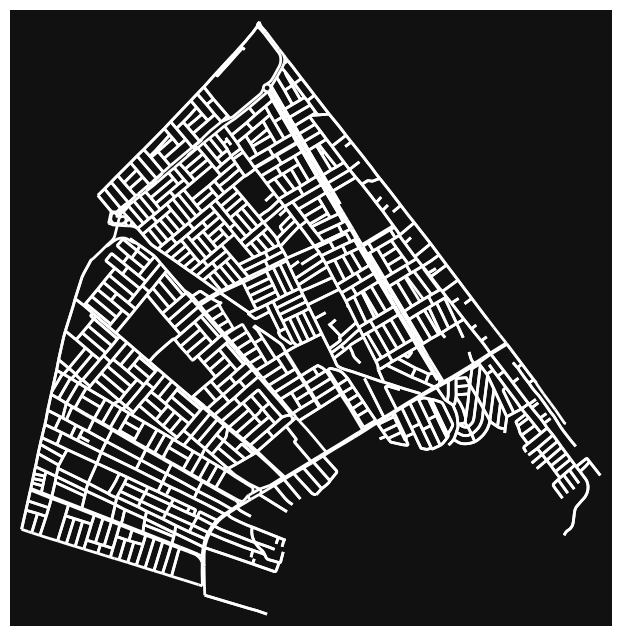

In [ ]:
place = "Potengi,Natal,Rio Grande do Norte" # Dica: Use o nome completo para evitar ambiguidades

# Criando o grafo
G = ox.graph_from_place(place, network_type="drive")

print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")

fig, ax = ox.plot.plot_graph(G, edge_color = "white", edge_linewidth = 2, node_size = 0,show = False, save = True, filepath = "/content/img/Natal_Zona_Norte.png")
plt.show()

## 📊 Conversão do Grafo e Cálculo das Métricas de Centralidade

Para a maioria das análises, convertemos o dígrafo original em um **grafo não-direcionado simples** (sem arestas paralelas e sem laços), pois as métricas clássicas de centralidade e de k-core são definidas para grafos simples.

Em seguida, calculamos as seguintes métricas para todos os nós da rede:

| Métrica | Descrição |
|---|---|
| **Grau (Degree)** | Número de arestas conectadas ao nó — indica conectividade local. |
| **Distribuição de Grau** | Frequência de cada valor de grau na rede. |
| **Hubs (Top 10)** | Os 10 nós com maior grau — pontos de maior conectividade. |
| **Betweenness Centrality** | Proporção de caminhos mínimos que passam pelo nó — revela gargalos globais. |
| **Closeness Centrality** | Inverso da soma das distâncias ao resto da rede — revela acessibilidade. |
| **Core Number** | K-core máximo ao qual cada nó pertence — mede coesão da vizinhança. |
| **K-Core / Main Core** | Subgrafos maximais onde todos os nós têm grau ≥ k — identifica o núcleo da rede. |

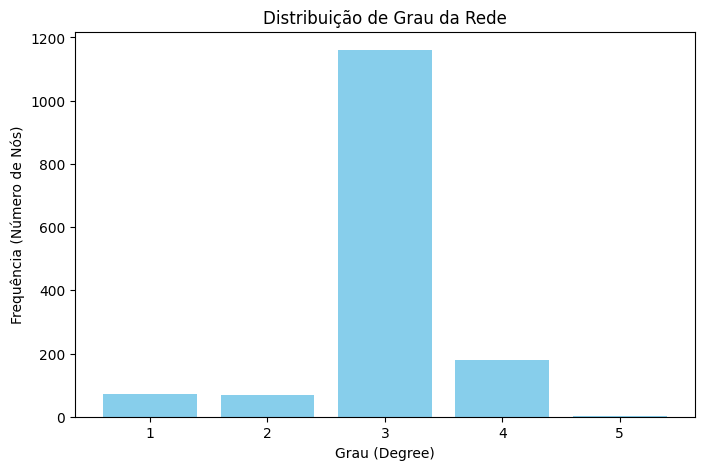

Top 10 Hubs (ID do Nó, Grau):
Nó: 558387303 | Grau: 5
Nó: 9457010523 | Grau: 5
Nó: 503486188 | Grau: 4
Nó: 503486208 | Grau: 4
Nó: 503486249 | Grau: 4
Nó: 503490685 | Grau: 4
Nó: 503490747 | Grau: 4
Nó: 503498649 | Grau: 4
Nó: 523913456 | Grau: 4
Nó: 523927135 | Grau: 4

A rede possui um K máximo de: 2
O 3-core possui 0 nós.
O Main Core (2-core) possui 1399 nós.


In [ ]:
# Converte o MultiDiGraph em um MultiGraph não-direcionado
G_undirected = ox.convert.to_undirected(G)

# Converte para um grafo simples (remove arestas paralelas)
G_simple = nx.Graph(G_undirected)

# Remove laços (self-loops) em um mesmo nó para as análises de K-Core
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

# ---------------------------------------------------------
# 1. GRAU DOS NÓS
# ---------------------------------------------------------
# Calcula o grau (soma de in-degree e out-degree) para cada nó no grafo original
graus = dict(G_undirected.degree())


# ---------------------------------------------------------
# 2. DISTRIBUIÇÃO DE GRAU
# ---------------------------------------------------------
# Conta a frequência de cada grau na rede
distribuição = Counter(graus.values())

# Plotando a distribuição de grau (Opcional, mas útil para análise visual)
plt.figure(figsize=(8, 5))
plt.bar(distribuição.keys(), distribuição.values(), color='skyblue')
plt.title('Distribuição de Grau da Rede')
plt.xlabel('Grau (Degree)')
plt.ylabel('Frequência (Número de Nós)')
plt.show()


# ---------------------------------------------------------
# 3. IDENTIFICAÇÃO DOS HUBS (Nós com Maior Grau)
# ---------------------------------------------------------
# Ordena o dicionário de graus em ordem decrescente
hubs_ordenados = sorted(graus.items(), key=lambda item: item[1], reverse=True)

# Seleciona os 10 principais Hubs
top_10_hubs = hubs_ordenados[:10]
print("Top 10 Hubs (ID do Nó, Grau):")
for node_id, degree in top_10_hubs:
    print(f"Nó: {node_id} | Grau: {degree}")


# ---------------------------------------------------------
# 4. BETWEENNESS CENTRALITY
# ---------------------------------------------------------
# AVISO: Pode ser muito custoso computacionalmente em grafos grandes.
# O uso de weight='length' considera a distância real da rua em vez de saltos (hops).
# Dica: Se a rede for gigante, adicione o parâmetro 'k=100' (exemplo) para usar uma amostra e aproximar o valor.
betweenness = nx.betweenness_centrality(G_undirected, weight='length', normalized=True)


# ---------------------------------------------------------
# 5. CLOSENESS CENTRALITY
# ---------------------------------------------------------
# Para o closeness, o parâmetro distance='length' garante que a distância real seja usada.
closeness = nx.closeness_centrality(G_undirected, distance='length')
#edge_centrality = nx.closeness_centrality(nx.line_graph(G))

# ---------------------------------------------------------
# 6. CORE NUMBER
# ---------------------------------------------------------
# Core number usa o grafo simples que preparamos no início.
# Ele retorna um dicionário onde a chave é o ID do nó e o valor é a qual k-core máximo ele pertence.
core_numbers = nx.core_number(G_simple)


# ---------------------------------------------------------
# 7. ANÁLISE DO K-CORE
# ---------------------------------------------------------
# Extrair um subgrafo específico (ex: o 3-core, onde todos os nós têm grau >= 3)
k = 3
k_core_subgraph = nx.k_core(G_simple, k=k)

# Extrair o "Main Core" (o K-core com o maior k possível na rede)
main_core = nx.k_core(G_simple)
k_maximo = max(core_numbers.values())

print(f"\nA rede possui um K máximo de: {k_maximo}")
print(f"O {k}-core possui {len(k_core_subgraph.nodes())} nós.")
print(f"O Main Core ({k_maximo}-core) possui {len(main_core.nodes())} nós.")

## 🔴 Visualização: Hubs, Gargalos e Sobreposição

Este bloco gera um mapa colorido da rede viária destacando três categorias de nós:

- 🔵 **Cyan** — *Hubs de Grau 5*: interseções com o maior grau na rede (mais ruas conectadas diretamente).
- 🟣 **Magenta** — *Gargalos (Top 10% Betweenness)*: nós que concentram a maior parte dos caminhos mínimos — pontos críticos para o fluxo global.
- ⚪ **Branco** — *Hub E Gargalo simultaneamente*: nós que são ao mesmo tempo muito conectados localmente e estruturalmente estratégicos para a mobilidade.

A identificação visual dessa sobreposição (ou ausência dela) é fundamental para entender se conectividade local e relevância global coincidem na malha urbana.

Gerando plot com 2 hubs (grau 5) em cyan, 148 gargalos (top 148 betweenness) em magenta, e 1 nós que são ambos em white...


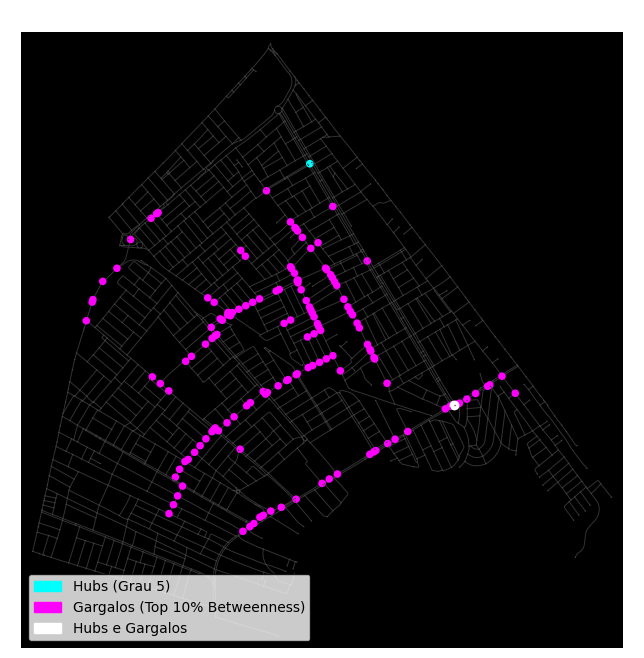

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd # Importar pandas

# 1. Identificar os Hubs de Grau 5
hubs_grau_5_ids = set([node_id for node_id, degree in hubs_ordenados if degree == 5]) # Convert to set for faster lookup

# 2. Identificar os "Gargalos" (Nós com Maior Betweenness Centrality)
# Usar a variável 'betweenness' que já foi calculada corretamente em células anteriores.
bet_values_dict = betweenness

# Converter para DataFrame para facilitar a ordenação e seleção
df_betweenness = pd.DataFrame(list(bet_values_dict.items()), columns=['node_id', 'betweenness'])
# Converter a coluna 'betweenness' para numérico
df_betweenness['betweenness'] = pd.to_numeric(df_betweenness['betweenness'])

# Selecionar o top 10% de nós com maior betweenness centrality
top_n_bottlenecks = max(1, int(len(df_betweenness) * 0.10))
bottleneck_nodes_ids = set(df_betweenness.nlargest(top_n_bottlenecks, 'betweenness')['node_id']) # Convert to set

# 2.5. Identificar nós que são Hubs E Gargalos
hub_and_bottleneck_nodes_ids = hubs_grau_5_ids.intersection(bottleneck_nodes_ids)

# 3. Preparar cores e tamanhos para o plot
node_colors = []
node_sizes = []

default_node_color = '#444444' # Cor padrão para nós normais, mais escuro
default_node_size = 1          # Tamanho padrão para nós normais, bem pequeno para focar nos destaques

hub_color = 'cyan'             # Cor para hubs de grau 5, alterado para cyan para maior contraste
hub_size = 30                  # Tamanho para hubs de grau 5, maior

bottleneck_color = 'magenta'   # Cor para gargalos, alterado para magenta para maior contraste
bottleneck_size = 30           # Tamanho para gargalos, maior

hub_bottleneck_color = 'white' # Nova cor para nós que são Hub E Gargalo
hub_bottleneck_size = 50       # Novo tamanho para nós que são Hub E Gargalo

for node in G_undirected.nodes():
    if node in hub_and_bottleneck_nodes_ids:
        node_colors.append(hub_bottleneck_color)
        node_sizes.append(hub_bottleneck_size)
    elif node in hubs_grau_5_ids:
        node_colors.append(hub_color)
        node_sizes.append(hub_size)
    elif node in bottleneck_nodes_ids:
        node_colors.append(bottleneck_color)
        node_sizes.append(bottleneck_size)
    else:
        node_colors.append(default_node_color)
        node_sizes.append(default_node_size)

# 4. Plotar o grafo
print(f"Gerando plot com {len(hubs_grau_5_ids)} hubs (grau 5) em {hub_color}, {len(bottleneck_nodes_ids)} gargalos (top {top_n_bottlenecks} betweenness) em {bottleneck_color}, e {len(hub_and_bottleneck_nodes_ids)} nós que são ambos em {hub_bottleneck_color}...")
fig, ax = ox.plot_graph(G_undirected, node_color=node_colors, node_size=node_sizes,
                        edge_color="#333333", edge_linewidth=0.7, # Linhas das arestas um pouco mais grossas
                        bgcolor="k", show=False, close=False)

# Adicionar legendas
import matplotlib.patches as mpatches
cyan_patch = mpatches.Patch(color='cyan', label='Hubs (Grau 5)')
magenta_patch = mpatches.Patch(color='magenta', label='Gargalos (Top 10% Betweenness)')
white_patch = mpatches.Patch(color='white', label='Hubs e Gargalos') # Nova entrada na legenda
plt.legend(handles=[cyan_patch, magenta_patch, white_patch], loc='lower left', frameon=True, facecolor='white', edgecolor='black')

plt.title("Rede Urbana: Hubs (Grau 5), Gargalos (Top Betweenness) e Hubs/Gargalos", color='white') # Título em branco para fundo escuro
plt.show()

## 🌡️ Mapas de Calor: Betweenness e Closeness Centrality

Aqui geramos três visualizações complementares para explorar a distribuição espacial das métricas de centralidade:

1. **Mapa de Betweenness Centrality** (paleta *inferno*): nós mais brilhantes/quentes concentram mais caminhos mínimos — são os gargalos da rede.
2. **Mapa de Closeness Centrality** (paleta *plasma*): nós mais brilhantes/amarelos têm melhor acesso global à rede — são os pontos mais acessíveis.
3. **Histogramas das distribuições**: revelam se as métricas são distribuídas de forma homogênea ou concentrada (cauda longa), o que indica o nível de heterogeneidade estrutural da rede.

Gerando mapa de Betweenness Centrality...


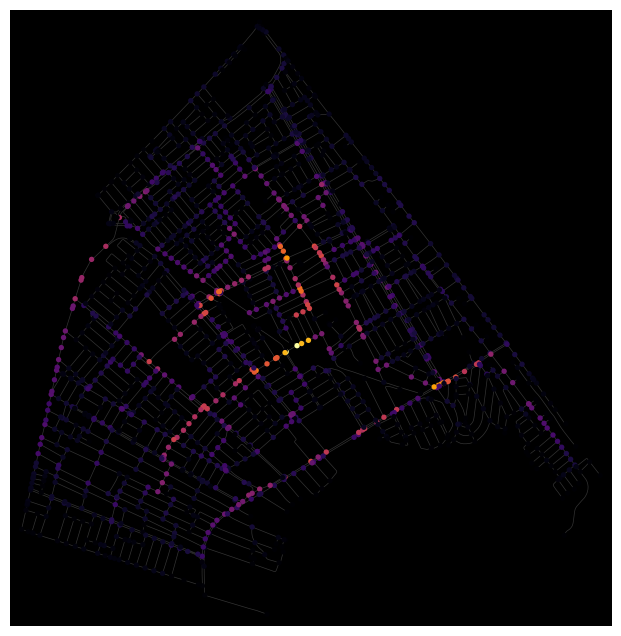

Gerando mapa de Closeness Centrality...


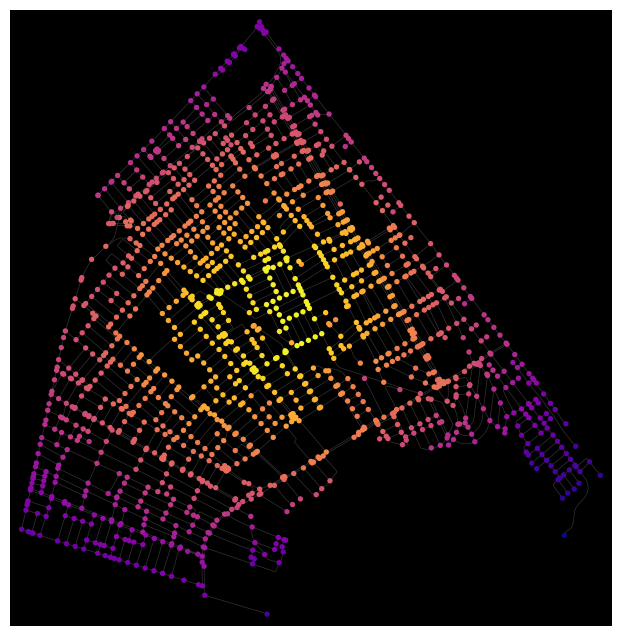

Gerando histogramas das distribuições...


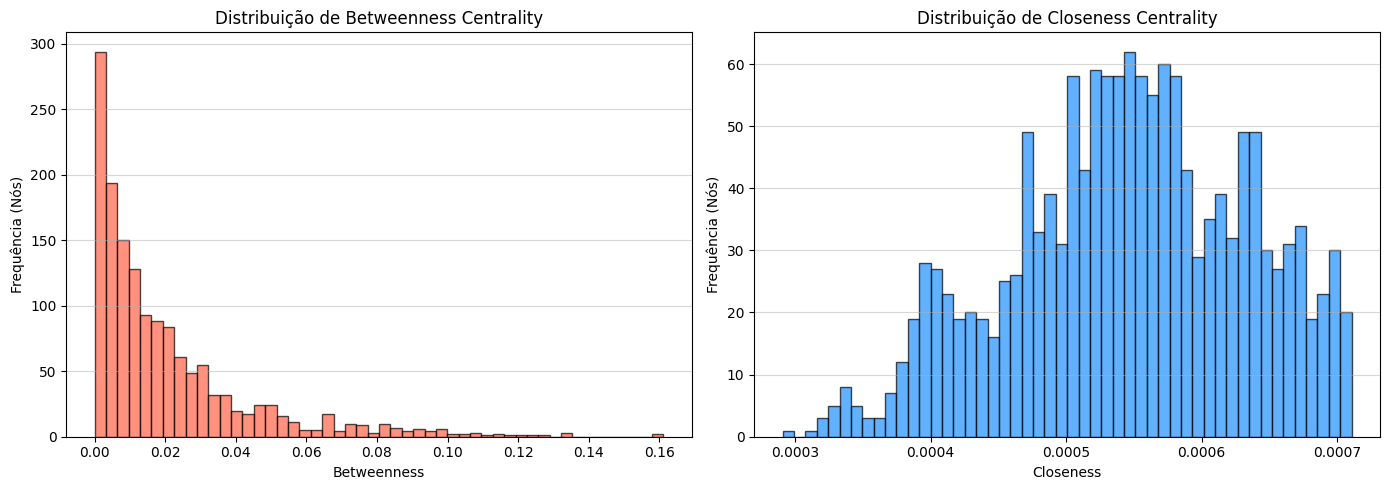

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# ---------------------------------------------------------
# PREPARAÇÃO: Adicionando as métricas como atributos dos nós
# ---------------------------------------------------------
nx.set_node_attributes(G_undirected, betweenness, 'betweenness')
nx.set_node_attributes(G_undirected, closeness, 'closeness')

# ---------------------------------------------------------
# VISUALIZAÇÃO 1: MAPA DE BETWEENNESS CENTRALITY
# ---------------------------------------------------------
# Extrai os valores para criar a escala de cor
bet_values = [data['betweenness'] for node, data in G_undirected.nodes(data=True)]

# Normaliza os valores e escolhe uma paleta de cores (ex: 'plasma', 'inferno', 'viridis')
norm_bet = colors.Normalize(vmin=min(bet_values), vmax=max(bet_values))
cmap_bet = cm.inferno
node_colors_bet = [cmap_bet(norm_bet(val)) for val in bet_values]

print("Gerando mapa de Betweenness Centrality...")
# Plotando no mapa do OSMnx (Nós mais brilhantes/quentes = Maior Betweenness)
fig1, ax1 = ox.plot_graph(G_undirected, node_color=node_colors_bet, node_size=15,
                          edge_color="#333333", edge_linewidth=0.5,
                          bgcolor="k", show=True)


# ---------------------------------------------------------
# VISUALIZAÇÃO 2: MAPA DE CLOSENESS CENTRALITY
# ---------------------------------------------------------
clos_values = [data['closeness'] for node, data in G_undirected.nodes(data=True)]

# Normaliza os valores para a escala de cor
norm_clos = colors.Normalize(vmin=min(clos_values), vmax=max(clos_values))
cmap_clos = cm.plasma
node_colors_clos = [cmap_clos(norm_clos(val)) for val in clos_values]

print("Gerando mapa de Closeness Centrality...")
# Plotando no mapa do OSMnx (Nós mais brilhantes/amarelos = Maior Closeness)
fig2, ax2 = ox.plot_graph(G_undirected, node_color=node_colors_clos, node_size=15,
                          edge_color="#333333", edge_linewidth=0.5,
                          bgcolor="k", show=True)


# ---------------------------------------------------------
# VISUALIZAÇÃO 3: HISTOGRAMAS (Distribuição Estatística)
# ---------------------------------------------------------
print("Gerando histogramas das distribuições...")
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma Betweenness
axes[0].hist(bet_values, bins=50, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribuição de Betweenness Centrality')
axes[0].set_xlabel('Betweenness')
axes[0].set_ylabel('Frequência (Nós)')
axes[0].grid(axis='y', alpha=0.5)

# Histograma Closeness
axes[1].hist(clos_values, bins=50, color='dodgerblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribuição de Closeness Centrality')
axes[1].set_xlabel('Closeness')
axes[1].set_ylabel('Frequência (Nós)')
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

## 🏷️ Adição de Atributos aos Nós do Grafo

Neste passo, armazenamos as métricas calculadas anteriormente (**grau** e **core number**) diretamente como atributos dos nós do grafo `G_undirected`.

Isso é necessário para exportar o grafo enriquecido em formato compatível com ferramentas de análise externas, como o **Gephi**.

In [ ]:
nx.set_node_attributes(G_undirected, graus, "degree")
nx.set_node_attributes(G_undirected, core_numbers, "core_number")

## 💾 Exportação do Grafo para o Gephi (GraphML)

Este bloco prepara e exporta o grafo com todas as métricas para o formato **GraphML**, compatível com o software de visualização de redes **Gephi**.

As etapas realizadas são:
1. Adicionar coordenadas geográficas (`Lat`, `Long`) como atributos de cada nó.
2. Salvar o grafo com `ox.save_graphml()` usando o modo `gephi=True`.
3. **Corrigir os tipos de dado** no arquivo XML gerado: o OSMnx salva alguns atributos numéricos como `string`, o que impede o Gephi de usá-los em filtros e layouts. O bloco substitui os tipos para `double` ou `int` conforme adequado.

In [ ]:
for node, data in G_undirected.nodes(data=True):
    data['Lat'] = float(data['y'])
    data['Long'] = float(data['x'])

ox.save_graphml(G_undirected, filepath="rede_urbana.graphml", gephi=True)

# Corrige o tipo de Lat e Long no arquivo
with open("rede_urbana.graphml", "r") as f:
    content = f.read()

content = content.replace('attr.name="Lat" attr.type="string"', 'attr.name="Lat" attr.type="double"')
content = content.replace('attr.name="Long" attr.type="string"', 'attr.name="Long" attr.type="double"')
content = content.replace('attr.name="betweenness" attr.type="string"', 'attr.name="betweenness" attr.type="double"')
content = content.replace('attr.name="closeness" attr.type="string"', 'attr.name="closeness" attr.type="double"')
content = content.replace('attr.name="core_number" attr.type="string"', 'attr.name="core_number" attr.type="int"')
content = content.replace('attr.name="degree" attr.type="string"', 'attr.name="degree" attr.type="int"')
content = content.replace('attr.name="street_count" attr.type="string"', 'attr.name="street_count" attr.type="int"')

with open("rede_urbana_2.graphml", "w") as f:
    f.write(content)

## 🔍 Inspeção de um Nó do Grafo

Bloco auxiliar de depuração: imprime todos os atributos armazenados no primeiro nó do grafo (`G_undirected`).

Útil para confirmar que as métricas (betweenness, closeness, core_number, degree, Lat, Long) foram corretamente atribuídas como atributos dos nós antes da exportação.

In [ ]:
node_id = list(G_undirected.nodes())[0]
print(G_undirected.nodes[node_id])

{'y': -5.7644265, 'x': -35.2544886, 'street_count': 3, 'betweenness': 0.006148237486979881, 'closeness': np.float64(0.0004456986630108638), 'degree': 3, 'core_number': 2, 'Lat': -5.7644265, 'Long': -35.2544886}


## 📐 Cálculo do Corte Percentil (Top 10% de Grau)

Calcula o valor de corte correspondente ao **percentil 90** da distribuição de graus da rede.

Este limiar é usado nas análises seguintes para definir, de forma objetiva e relativa ao tamanho da rede, quais nós são considerados **principais hubs** (os 10% com maior grau).

In [ ]:
import numpy as np
graus_valores = list(dict(G_undirected.degree()).values())
corte = np.percentile(graus_valores, 90)
print(f"Corte 10% maiores: {corte}")

Corte 10% maiores: 4.0


# Respostas das perguntas obrigatórias

### Os nós com maior grau coincidem com os nós de maior betweenness?

Os nós com maior grau não coincidem com os nós de maior betweenness (intermediação). Numa malha viária, o grau de um nó é limitado pela geometria física das esquinas (quase todos os cruzamentos têm apenas 3 ou 4 conexões directas), gerando centenas de nós empatados com o mesmo grau máximo. Em contrapartida, a centralidade de betweenness destaca a importância macroscópica e estrutural do nó na cidade, identificando pontes, viadutos ou avenidas principais que canalizam o tráfego global e funcionam como caminhos mais curtos entre diferentes bairros, independentemente de terem muitas ou poucas ruas conectadas directamente a eles.

### O núcleo identificado pelo k-core coincide com os principais hubs?

o núcleo identificado pelo k-core não coincide com os principais hubs. Nesta rede, os maiores hubs são nós isolados com grau 4 ou ligeiramente maior, correspondendo a rotatórias de grande porte ou cruzamentos complexos dispersos (muitos deles localizados em rodovias de acesso ou na periferia, onde o desenho das vias converge para poucos pontos). Por outro lado, como os nós de uma malha urbana possuem uma limitação física de conexões diretas por causa da geometria das ruas, a decomposição em 2-core elimina progressivamente essas ramificações periféricas e os hubs isolados. O núcleo resultante (o max core) se concentra na região com a malha viária mais densa, compacta e intensamente quadriculada do mapa — tipicamente áreas centrais e comerciais consolidadas, onde os nós formam um bloco altamente resiliente e interconectado, mesmo que individualmente cada cruzamento ali dentro tenha poucas vias conectadas a ele.

### O que a métrica de betweenness revela que o grau não revela?

Para este grafo específico do Potengi, o grau falha completamente em diferenciar a relevância das vias porque atribui exatamente o mesmo peso a uma esquina residencial interna e a um eixo logístico vital. Por exemplo, um cruzamento comum de 4 esquinas nas ruas residenciais internas do conjunto Santarém ou do Soledade terá grau=4, exatamente o mesmo grau de um nó crucial nas alças de acesso que conectam o fluxo interno do bairro à Avenida João Medeiros Filho (RN-160). O grau olha apenas para o número de ruas que chegam ao nó no nível micro, tratando uma rua sem saída e um corredor de transporte de massa como geometricamente idênticos.

A métrica de betweenness, por outro lado, revela a dependência estrutural do fluxo e os verdadeiros gargalos do Potengi, algo que fica nitidamente claro ao analisar o contraste entre as duas imagens. No layout geográfico, as vias parecem distribuídas de forma homogênea, mas o betweenness arranca essa máscara e, no layout estrutural, violenta e magneticamente puxa os nós centrais da Avenida João Medeiros Filho e das aproximações da Avenida Itapetinga para o centro absoluto do grafo. Essa métrica revela que esses pontos específicos funcionam como pontes e cordões umbilicais obrigatórios: eles canalizam os caminhos mais curtos que conectam os subconjuntos residenciais periféricos (que o layout estrutural joga para as margens) às saídas estratégicas em direção às pontes de Igapó e Newton Navarro. O betweenness revela, portanto, quais nós colapsariam e isolariam o Potengi do restante de Natal caso fossem bloqueados, enquanto o grau esconde essa vulnerabilidade sob a aparente igualdade de cruzamentos com 3 ou 4 conexões.

### O que muda quando a rede é analisada em sua posição geográfica real e quando é analisada por um layout estrutural?

A mudança entre a visualização geográfica real e o layout estrutural altera completamente a nossa percepção sobre o papel socioespacial de cada bairro e infraestrutura viária:

No layout geográfico real, a rede é rigidamente ditada pelo mapa físico, espelhando a disposição das ruas paralelas e os limites territoriais do Potengi. Essa visualização esconde o verdadeiro peso das vias principais, pois grandes avenidas parecem apenas linhas longas que ocupam espaço, enquanto as áreas residenciais periféricas e os conjuntos mais distantes parecem isolados ou desconectados do funcionamento geral do bairro.

Já no layout estrutural, a geometria física é ignorada e a rede é rearranjada puramente pela conectividade (topologia). Ao mesmo tempo, os tecidos urbanos densamente quadriculados (como o interior do conjunto Santarém) colapsam em aglomerados compactos devido à sua alta conectividade interna (k-core elevado), enquanto as ruas sem saída e os conjuntos residenciais mais isolados são jogados para as margens do grafo, desmascarando a desigualdade na infraestrutura de mobilidade do bairro.

### Existem regiões críticas para mobilidade urbana na área analisada?

A principal região crítica para a mobilidade na área estudada concentra-se no corredor estrutural da Avenida Doutor João Medeiros Filho (RN-302). Por se tratar de uma via arterial primária de alta capacidade, ela centraliza a maior parte do fluxo regional, convertendo-se em um gargalo estrutural. Suas interseções semafóricas e a conexão com importantes eixos secundários (como as Avenidas Maranguape, Rio Doce e Doutor José Francisco da Silva) geram pontos de retenção crônica, onde qualquer perturbação no tráfego provoca um efeito em cadeia imediato na acessibilidade das vias residenciais adjacentes.

### A rede parece homogênea ou apresenta concentração estrutural?

A malha urbana analisada é fortemente heterogênea e apresenta uma clara concentração estrutural. Em vez de uma distribuição equilibrada do fluxo, a rede depende de um padrão radiocêntrico e linear focado no eixo da Avenida Doutor João Medeiros Filho. Essa via primária e suas principais conexões atuam como verdadeiros "funis" de tráfego, concentrando os maiores índices de centralidade e conectividade regional. Enquanto a maior parte da rede é composta por ruas secundárias e locais de baixa capacidade, a mobilidade global do sistema fica vulnerável e altamente dependente de um número restrito de corredores estruturais.

### Os resultados obtidos fazem sentido considerando o conhecimento urbano da região escolhida?

Sim, os resultados fazem total sentido e refletem com precisão a realidade do bairro Potengi na zona norte de Natal. O eixo modelado da Avenida Doutor João Medeiros Filho (RN-302) é, de fato, uma importante via de tráfego da região, conectando a zona norte de natal, que é predominantemente mais residencial, à Ponte Newton Navarro e a Ponte de Igapó e ao restante da cidade. A identificação de forte concentração estrutural no modelo coincide com o histórico problema de isolamento e dependência dessa via única para o deslocamento diário da população, validando o grafo como uma representação fiel dos gargalos e da vulnerabilidade na infraestrutura de mobilidade local.